# Exercise - Decoupling of Printed Circuit Boards - 2)

Exercise in the lecture Machine Learning in Electrical Engineering and Information Technology, Decoupling of Printed Circuit Boards

* Lecture Period: Summer 2024 ([StudIP](https://e-learning.tuhh.de/studip/dispatch.php/course/overview?cid=ad2748a23022bc374228b4671f8dc508))
* Institute: Institut für Theoretische Elektrotechnik ([TET](https://www.tet.tuhh.de/en/institute/))
* University: Hamburg University of Technology ([TUHH](https://www.tuhh.de/tuhh/en/startpage))
* Exercise Supervisor: Til Hillebrecht and Jan Heßling



**Task 2** is about variations of Power Delivery Networks (PDNs). Including variations of decoupling capacitors (**Task 2 a)**), variations of printed circuits board (PCB) geometries and materials and looked at in part b).  
In part **c)** you can combine different data sets, training different kind of machine learning tools. If you want, you can try to train support vector machines, nearest neighbor methods, or decision trees.  
Have a look at [scikit-learn](https://scikit-learn.org/stable/index.html) if you need further information about training different kind of machine learning tools.

You find three different kind of data sets in the data folder.
* Direct Preprocessing *direct_preproc_decap.csv*
* Rectangular Preprocessing *rectangular_preproc_decap.csv*
* Ring Preprocessing *ring_preproc_decap.csv*

From the helper module you can use the *data_loader* function, loading the corresponding function, including variations of the PCB or not. One example is given in the following cell. Further information how to load, split, preprocess the data can be taken from the previous exercises.



**Variables**  
* *preproc*: choose the preprocssing method from [ring, rectangular, direct]
* *pcb_variations*: include variations of the PCB, [True, False]

**Output**  
From the cells below you get the full data (*data*) set as output. Additionally, you get the feature names for input (*input_features*) and feature name for output (*output_features*).
* *data*: Full data set
* *input_features*: Feature input name
* *output_features*: Feature output name

In [77]:
# variables

preproc = 'ring'
pcb_variations = False

In [78]:
import helper.helper_functions as hp

data = hp.get_data(preprocessing=preproc, pcb_variations=pcb_variations)
input_features = list()
output_features = list()
for column in data.columns:
    if column != 'targetMet':
        input_features.append(column)
    else:
        output_features.append(column)

### Evaluation of Classification Problems

Evaluating classification problems can be more difficult sometimes. Therefore, looking at a metrics is not always sufficient e.g. mean-squared-error.
A [confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) can help to understand the results better.  
For a problem with two classes (e.g. Target Impedance Violated &rarr; [Yes, No]) the confusion matrix provides 4 values.
* Correct *Yes* Predictions (True Positive), high number wanted
* Wrong *Yes* Predictions (False Positive), low number wanted
* Correct *No* Predictions (True Negative), high number wanted
* Wrong *No* Predictions (False Negative), low number wanted

In the following cell you find a confusion matrix for some **random** data with 1000 data points.

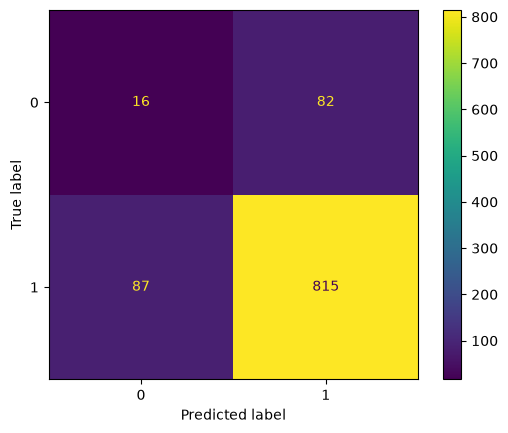

In [79]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

true_values = np.random.randint(10, size=1000)
predicted_values = np.random.randint(10, size=1000)
true_values[true_values > 1] = 1
predicted_values[predicted_values > 1] = 1

cm = confusion_matrix(true_values, predicted_values)
cm_display = ConfusionMatrixDisplay(cm).plot()

# Your Code comes Here!

Do not put everything in one cell. You can split your data in individual sections, similar to the previous tasks. Remember the following points:

* Prepare your data (Splitting, Scaling)
* Visualize your data (train, test) distributions
* Decide on your machine learning (ML) tool e.g. neural network
* Setup your ML tools
* Train your ML tool
* Evaluate your ML tool

You can **copy** the notebook for the different subtasks also.

## Task 2 - Classification pipeline for one preprocessing configuration

This first worked example uses the selected preprocessing variables above.

In [80]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
X = data[input_features].copy()
y = data[output_features[0]].astype(int)
assert not X.isna().any().any()
print(f'{len(X):,} samples, {X.shape[1]} features')
display(y.value_counts().rename(index={0:'target violated',1:'target met'}).to_frame('count'))

13,157 samples, 60 features


,count
targetMet,
target violated,7755
target met,5402


### 1. Prepare and visualize the data

The stratified 70/15/15 split preserves both classes. Scaling is fitted inside the logistic-regression pipeline to avoid leakage.

,train,validation,test
targetMet,,,
violated,5428,1163,1164
met,3781,811,810


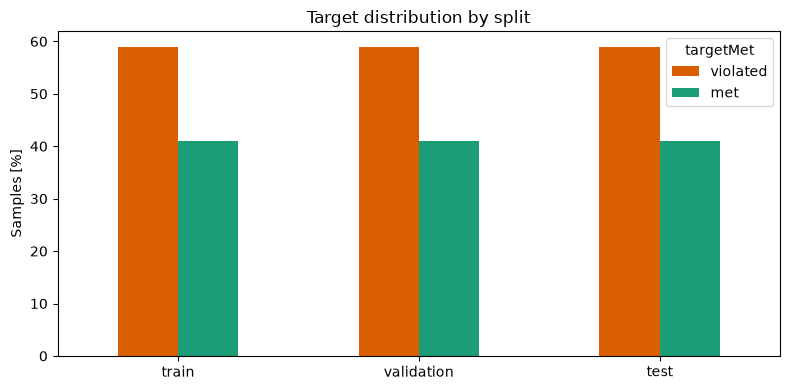

In [83]:
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=.30,stratify=y,random_state=RANDOM_STATE)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp,y_temp,test_size=.50,stratify=y_temp,random_state=RANDOM_STATE)
counts=pd.DataFrame({'train':y_train.value_counts(),'validation':y_valid.value_counts(),'test':y_test.value_counts()}).rename(index={0:'violated',1:'met'})
display(counts)
ax=(counts/counts.sum()*100).T.plot.bar(figsize=(8,4),color=['#d95f02','#1b9e77'])
ax.set(title='Target distribution by split',ylabel='Samples [%]',xlabel=''); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 2. Set up, train, and select the ML model

Logistic regression is the scaled linear baseline. Random forest captures nonlinear capacitor interactions. Validation ROC-AUC selects the better model.

In [14]:
models={
 'Logistic regression':Pipeline([('scale',StandardScaler()),('model',LogisticRegression(max_iter=2000,solver='liblinear',class_weight='balanced',random_state=RANDOM_STATE))]),
 'Random forest':RandomForestClassifier(n_estimators=300,min_samples_leaf=2,class_weight='balanced_subsample',n_jobs=1,random_state=RANDOM_STATE)}
rows=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_valid); prob=model.predict_proba(X_valid)[:,1]
    report=classification_report(y_valid,pred,output_dict=True,zero_division=0)
    rows.append({'model':name,'ROC-AUC':roc_auc_score(y_valid,prob),'accuracy':report['accuracy'],'macro F1':report['macro avg']['f1-score']})
results=pd.DataFrame(rows).set_index('model').sort_values('ROC-AUC',ascending=False)
display(results.style.format('{:.3f}'))

,ROC-AUC,accuracy,macro F1
model,,,
Logistic regression,0.946,0.872,0.869
Random forest,0.940,0.865,0.861


### 3. Final test evaluation

The selected model is refitted on training plus validation data and evaluated once on the untouched test set.

Selected: Logistic regression
Test ROC-AUC: 0.9577
                 precision    recall  f1-score   support

target violated       0.91      0.88      0.90      1164
     target met       0.84      0.87      0.86       810

       accuracy                           0.88      1974
      macro avg       0.87      0.88      0.88      1974
   weighted avg       0.88      0.88      0.88      1974



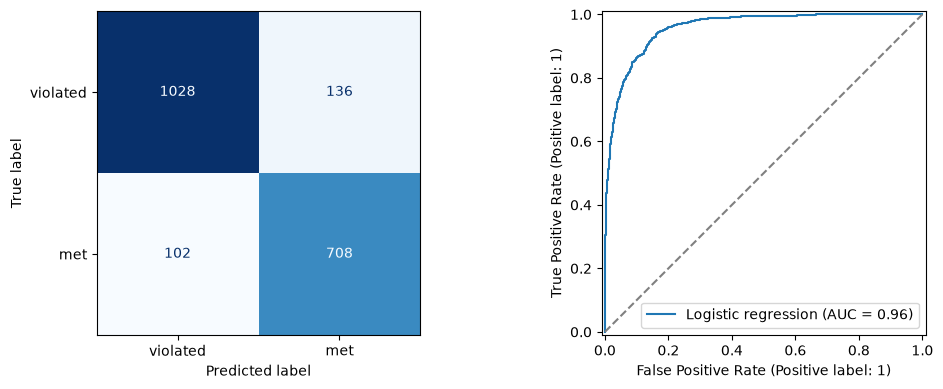

In [15]:
best_name=results.index[0]
best_model=clone(models[best_name])
best_model.fit(pd.concat([X_train,X_valid]),pd.concat([y_train,y_valid]))
test_pred=best_model.predict(X_test); test_prob=best_model.predict_proba(X_test)[:,1]
print('Selected:',best_name)
print(f'Test ROC-AUC: {roc_auc_score(y_test,test_prob):.4f}')
print(classification_report(y_test,test_pred,target_names=['target violated','target met'],zero_division=0))
fig,axes=plt.subplots(1,2,figsize=(11,4))
ConfusionMatrixDisplay.from_predictions(y_test,test_pred,display_labels=['violated','met'],cmap='Blues',colorbar=False,ax=axes[0])
RocCurveDisplay.from_predictions(y_test,test_prob,name=best_name,ax=axes[1]); axes[1].plot([0,1],[0,1],'--',color='grey'); plt.tight_layout(); plt.show()

### 4. Interpret important PCB/decap features

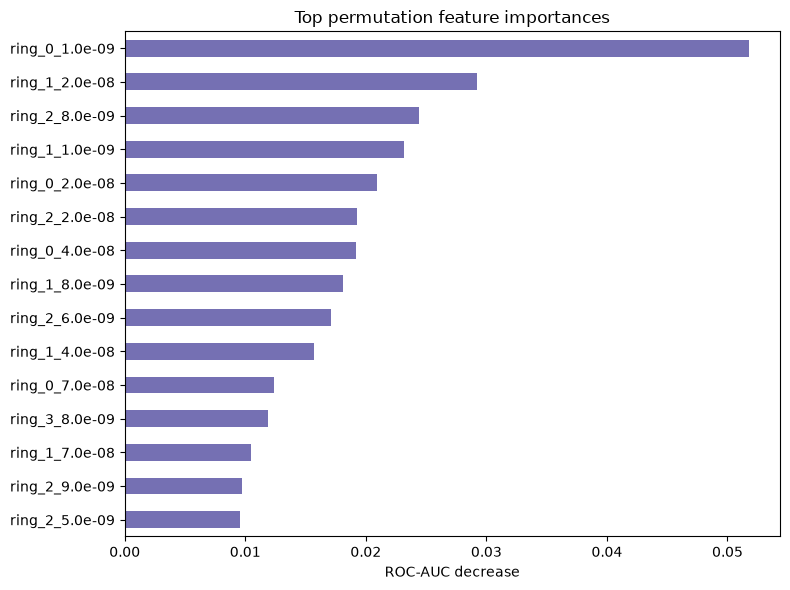

,importance
ring_0_1.0e-09,0.051767
ring_1_2.0e-08,0.029256
ring_2_8.0e-09,0.024386
ring_1_1.0e-09,0.023204
ring_0_2.0e-08,0.020930
ring_2_2.0e-08,0.019282
ring_0_4.0e-08,0.019223
ring_1_8.0e-09,0.018123
ring_2_6.0e-09,0.017102
ring_1_4.0e-08,0.015681


In [16]:
importance=permutation_importance(best_model,X_test,y_test,scoring='roc_auc',n_repeats=3,random_state=RANDOM_STATE,n_jobs=1)
top=pd.Series(importance.importances_mean,index=X.columns,name='importance').nlargest(15).sort_values()
top.plot.barh(figsize=(8,6),color='#7570b3',title='Top permutation feature importances'); plt.xlabel('ROC-AUC decrease'); plt.tight_layout(); plt.show()
display(top.sort_values(ascending=False).to_frame())

## Full Task II comparison

This section completes comparisons across all three preprocessing representations, fixed versus varied PCB parameters, three classifier families (including an ANN), and a combined-feature dataset.

In [17]:
from sklearn.neural_network import MLPClassifier
def make_models():
    return {'Logistic regression':Pipeline([('scale',StandardScaler()),('model',LogisticRegression(max_iter=2000,solver='liblinear',class_weight='balanced',random_state=RANDOM_STATE))]),'Random forest':RandomForestClassifier(n_estimators=200,min_samples_leaf=2,class_weight='balanced_subsample',n_jobs=1,random_state=RANDOM_STATE),'MLP (ANN)':Pipeline([('scale',StandardScaler()),('model',MLPClassifier(hidden_layer_sizes=(48,),max_iter=150,early_stopping=True,validation_fraction=.15,n_iter_no_change=10,random_state=RANDOM_STATE))])}
def evaluate_configuration(X_cfg,y_cfg,preprocessing,pcb_case):
    X_tr,X_te,y_tr,y_te=train_test_split(X_cfg,y_cfg.astype(int),test_size=.20,stratify=y_cfg,random_state=RANDOM_STATE)
    rows=[]
    for model_name,model in make_models().items():
        model.fit(X_tr,y_tr); pred=model.predict(X_te); prob=model.predict_proba(X_te)[:,1]
        report=classification_report(y_te,pred,output_dict=True,zero_division=0)
        rows.append({'preprocessing':preprocessing,'PCB variations':pcb_case,'model':model_name,'samples':len(X_cfg),'features':X_cfg.shape[1],'ROC-AUC':roc_auc_score(y_te,prob),'accuracy':report['accuracy'],'macro F1':report['macro avg']['f1-score']})
    return rows

### Task 2a and 2b: preprocessing and PCB-variation comparison

Each representation is evaluated with decap-only variation and with PCB geometry/material variations.

In [18]:
benchmark_rows=[]
for prep_name in ['direct','rectangular','ring']:
    for include_pcb in [False,True]:
        cfg=hp.get_data(preprocessing=prep_name,pcb_variations=include_pcb)
        benchmark_rows.extend(evaluate_configuration(cfg.drop(columns='targetMet'),cfg['targetMet'],prep_name,include_pcb))
benchmark=pd.DataFrame(benchmark_rows).sort_values('ROC-AUC',ascending=False).reset_index(drop=True)
display(benchmark.style.format({'ROC-AUC':'{:.3f}','accuracy':'{:.3f}','macro F1':'{:.3f}'}))

,preprocessing,PCB variations,model,samples,features,ROC-AUC,accuracy,macro F1
0,ring,True,MLP (ANN),33289,62,0.976,0.914,0.911
1,ring,True,Random forest,33289,62,0.964,0.896,0.892
2,ring,True,Logistic regression,33289,62,0.963,0.896,0.893
3,ring,False,MLP (ANN),13157,60,0.963,0.894,0.891
4,ring,False,Logistic regression,13157,60,0.950,0.874,0.871
5,ring,False,Random forest,13157,60,0.943,0.861,0.857
6,rectangular,True,MLP (ANN),33605,62,0.933,0.855,0.849
7,rectangular,True,Logistic regression,33605,62,0.926,0.853,0.849
8,rectangular,True,Random forest,33605,62,0.922,0.840,0.835
9,direct,True,Random forest,35728,122,0.921,0.836,0.826


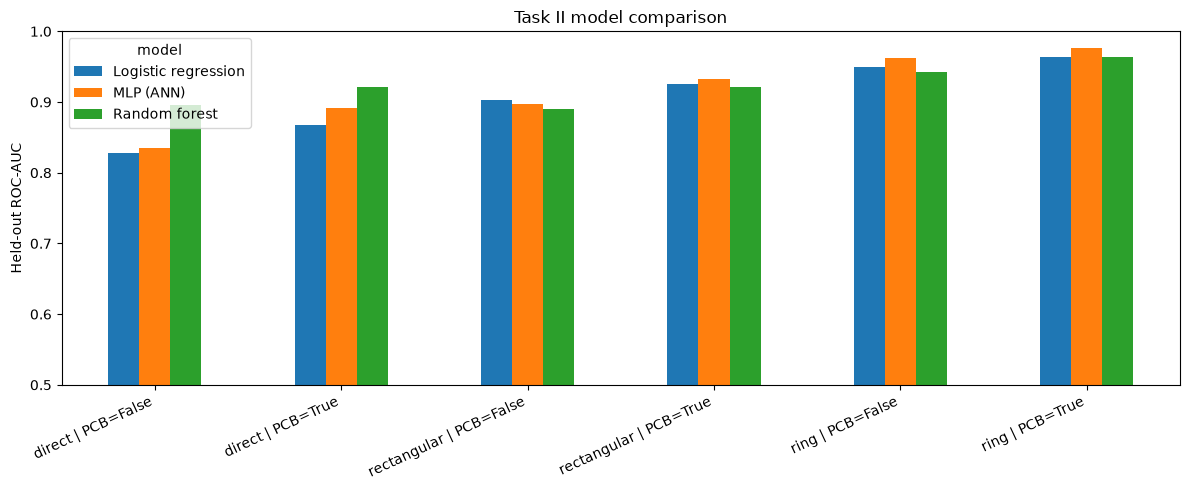

In [19]:
plot_data=benchmark.copy(); plot_data['configuration']=plot_data['preprocessing']+' | PCB='+plot_data['PCB variations'].astype(str)
ax=plot_data.pivot(index='configuration',columns='model',values='ROC-AUC').plot.bar(figsize=(12,5),ylim=(.5,1))
ax.set(title='Task II model comparison',ylabel='Held-out ROC-AUC',xlabel=''); plt.xticks(rotation=25,ha='right'); plt.tight_layout(); plt.show()

### Task 2c: combined preprocessing representations

The three feature tables are joined on their common simulation indices. Target values must agree before the join.

In [20]:
representations={n:hp.get_data(preprocessing=n,pcb_variations=True) for n in ['direct','rectangular','ring']}
common_index=sorted(set.intersection(*(set(f.index) for f in representations.values())))
targets=[f.loc[common_index,'targetMet'].astype(int) for f in representations.values()]
assert all(targets[0].equals(other) for other in targets[1:])
parts=[]
for name,frame in representations.items():
    features=frame.loc[common_index].drop(columns='targetMet')
    if name!='direct': features=features.drop(columns=['diel_height_y','epsilon_r_y'])
    parts.append(features.add_prefix(name+'_'))
X_combined=pd.concat(parts,axis=1); y_combined=targets[0]
print(f'Combined: {X_combined.shape[0]:,} samples, {X_combined.shape[1]} features')
combined_results=pd.DataFrame(evaluate_configuration(X_combined,y_combined,'combined',True))
display(combined_results.sort_values('ROC-AUC',ascending=False).style.format({'ROC-AUC':'{:.3f}','accuracy':'{:.3f}','macro F1':'{:.3f}'}))

Combined: 32,749 samples, 242 features


,preprocessing,PCB variations,model,samples,features,ROC-AUC,accuracy,macro F1
2,combined,True,MLP (ANN),32749,242,0.965,0.894,0.891
0,combined,True,Logistic regression,32749,242,0.961,0.891,0.888
1,combined,True,Random forest,32749,242,0.958,0.883,0.879


### Task 2d: overall comparison and conclusion

In [21]:
all_results=pd.concat([benchmark,combined_results],ignore_index=True).sort_values('ROC-AUC',ascending=False).reset_index(drop=True)
display(all_results.head(10).style.format({'ROC-AUC':'{:.3f}','accuracy':'{:.3f}','macro F1':'{:.3f}'}))
winner=all_results.iloc[0]
print(f"Best overall: {winner['preprocessing']} | PCB={winner['PCB variations']} | {winner['model']} | ROC-AUC={winner['ROC-AUC']:.4f}")

,preprocessing,PCB variations,model,samples,features,ROC-AUC,accuracy,macro F1
0,ring,True,MLP (ANN),33289,62,0.976,0.914,0.911
1,combined,True,MLP (ANN),32749,242,0.965,0.894,0.891
2,ring,True,Random forest,33289,62,0.964,0.896,0.892
3,ring,True,Logistic regression,33289,62,0.963,0.896,0.893
4,ring,False,MLP (ANN),13157,60,0.963,0.894,0.891
5,combined,True,Logistic regression,32749,242,0.961,0.891,0.888
6,combined,True,Random forest,32749,242,0.958,0.883,0.879
7,ring,False,Logistic regression,13157,60,0.950,0.874,0.871
8,ring,False,Random forest,13157,60,0.943,0.861,0.857
9,rectangular,True,MLP (ANN),33605,62,0.933,0.855,0.849


Best overall: ring | PCB=True | MLP (ANN) | ROC-AUC=0.9760
